In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

importlib.reload(main_functions) 
from main_functions import *

In [23]:
rosneft = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\ROSN.txt')
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_1candle_rosneft.pkl', 'rb') as file:
    rosneft_result = pickle.load(file)
display(rosneft_result.head(3))
display(rosneft.head(2))

,ticker,strategy name,period,N,lower_shadow_rate,up_shadow_rate,body_rate,count of trades,profit factor,total percent return,...,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model
0,ROSN,inverted_hummer,15 min,45,0.05,2.0,0.3,1299,1.147,155.31,...,26.6,time 2009-01-11 14:30:00 104985.000000 2009...,time 2009-01-11 14:30:00 105036.000000 2009...,time 2009-01-11 14:30:00 0.04985 2009-01-22...,time 2009-01-11 14:30:00 0.05036 2009-01-22...,21.0,24.0,20.0,22.5,87.5
1,ROSN,inverted_hummer,15 min,40,0.05,2.0,0.3,1383,1.140,144.92,...,32.2,time 2009-01-11 14:30:00 103873.000000 2009...,time 2009-01-11 14:30:00 103924.000000 2009...,time 2009-01-11 14:30:00 0.03873 2009-01-22...,time 2009-01-11 14:30:00 0.03924 2009-01-22...,20.0,22.0,23.5,12.5,78.0
2,ROSN,inverted_hummer,15 min,45,0.05,2.5,0.3,1252,1.129,114.72,...,25.7,time 2009-01-11 14:30:00 104985.000000 2009...,time 2009-01-11 14:30:00 105036.000000 2009...,time 2009-01-11 14:30:00 0.04985 2009-01-22...,time 2009-01-11 14:30:00 0.05036 2009-01-22...,18.5,14.5,20.0,24.0,77.0


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,ROSN,1,20090111,103000,114.90,114.90,113.03,113.1,95460
1,ROSN,1,20090111,103100,113.31,113.75,112.04,112.4,89619


In [24]:
tatneft_graph = good_dataframe(rosneft, timeframe='15 min')

In [25]:
def detection_of_inverted_hammer(data, lower_shadow_rate=0.05, body_rate=0.3, up_shadow_rate=2):

    """
    Обнаружение паттерна "Перевернутый молот".
    
    Условия:
        - Тело свечи ≤ 30% от всей свечи
        - Верхняя тень ≥ 10% от тела
        - Нижняя тень ≤ 2× тела
    
    Args:
        data: DataFrame с колонками open, high, low, close
        lower_shadow_rate: макс. соотношение нижней тени к телу (по умолч. 0.1)
        body_rate: макс. соотношение тела к свече (по умолч. 0.3)
        up_shadow_rate: мин. соотношение верхней тени к телу (по умолч. 2)
    
    Returns:
        data с колонками:
            - pattern: 1 - найден паттерн
            - signal: 1 - сигнал на покупку (на следующей свече)
            - strategy: 'inverted_hummer'
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'inverted_hummer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации перевернутый молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body < lower_shadow_rate) &
                      (up_shadow / body > up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [26]:
def preperation_to_modeling_1candle(data, period, func, N, profit):
    """Функция предназначена для подготовки датафрейма к дальнейшему моделированию

    Args:
        data (pd.DataFrame): 1-минутный таймфрейм
        period (object): Передаем период из стратегии
        func (function): Какой паттерн проверяем?
        N (int): Сколько следующих свеч удерживаем паттерн?
        profit (pd.Series): Численные результаты торгов

    Returns:
        Подготовленный датафрейм для использования ml
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(data_timeframe)
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal'] = data_filter['signal'].shift(-1)
    
    
    data_filter.drop(['pattern', 'lower_shadow_rate', 'up_shadow_rate', 'body_rate', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[0, 'profit percent net']
    data_filter = data_filter.set_index('time')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    final_data.dropna(inplace=True)
    return final_data

df = preperation_to_modeling_1candle(rosneft, '15 min', detection_of_inverted_hammer, 45, rosneft_result)

In [27]:
df

,time,open,high,low,close,volume,signal,profit_percent_net
0,2009-01-11 10:30:00,114.90,114.90,112.04,113.00,344582,0.0,0.0
1,2009-01-11 10:45:00,113.05,114.90,113.05,114.71,382404,0.0,0.0
2,2009-01-11 11:00:00,114.71,115.85,114.35,115.30,299301,0.0,0.0
3,2009-01-11 11:15:00,115.16,115.29,114.01,114.30,141403,0.0,0.0
4,2009-01-11 11:30:00,114.34,114.95,114.15,114.30,66214,0.0,0.0
...,...,...,...,...,...,...,...,...
186613,2026-03-31 22:15:00,483.60,483.65,482.70,483.00,24753,0.0,0.0
186614,2026-03-31 22:30:00,482.95,483.00,482.60,483.00,17487,0.0,0.0
186615,2026-03-31 22:45:00,482.95,483.45,482.90,483.30,56364,0.0,0.0
186616,2026-03-31 23:00:00,483.35,483.35,482.50,482.65,52190,0.0,0.0


In [28]:
# Признаки по дате и времени
def data_time_features(data):
    """Функция для создания временных признаков

    Args:
        data (pd.DataFrame): Датафрейм с разметкой данных

    Returns:
       data (pd.DataFrame): Новый датафрейм с временными признаками
    """
    data = data.copy()
    data['time'] = pd.to_datetime(data['time'])
    data['months'] = data['time'].dt.month
    data['days'] = data['time'].dt.day
    data['hours'] = data['time'].dt.hour
    data['day_of_week'] = data['time'].dt.day_of_week
    return data

In [29]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """
    Расчет характеристик свечей для ML-моделей.
    
    Признаки для текущей свечи (N):
        - has_body: наличие тела свечи
        - ratio_body_to_all_candle: отношение тела к полному диапазону (High-Low)
        - ratio_up_shadow_to_body: отношение верхней тени к телу
        - ratio_low_shadow_to_body: отношение нижней тени к телу
        - ratio_up_to_low_shadow: соотношение верхней и нижней теней
        - has_both_shadows: наличие обеих теней
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)"""
    data = data.copy()
    # Отношение тела свечи ко всей свече
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    
    # есть ли тело и есть ли свеча
    data['has_body'] = (body > 0).astype('int')
    data['has_full_candle'] = (full_candle > 0).astype('int')
    
    data['ratio_body_to_all_candle'] = np.where(full_candle > 0, body / full_candle, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    data['ratio_up_shadow_to_body'] = np.where(body > 0, up_shadow / body, np.nan)


    # Отношение нижней тени к телу свечи
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    
    data['ratio_low_shadow_to_body'] = np.where(body > 0, low_shadow / body, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow'] = np.where((low_shadow > 0) & (up_shadow > 0), up_shadow / low_shadow, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows'] = ((low_shadow > 0) & (up_shadow > 0)).astype('int')

    data = data.fillna(0)

    
    return data

In [30]:
def data_one_candle_features_2(data):
    """Расчет ATR-нормированных признаков свечей.
    
    Признаки (нормированы на ATR):
        - body_ATR: размер тела свечи
        - full_candle_ATR: полный диапазон High-Low
        - up_shadow_ATR: верхняя тень
        - low_shadow_ATR: нижняя тень
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Отфильтрованный DataFrame (удалены строки без ATR) с добавленными признаками"""
    
    data = data.copy()
    def ATR(data, period=14):
        high = data['high']
        low = data['low']
        close = data['close']
        
        # True Range компоненты
        high_low = high - low                                    # текущий бар
        high_close_prev = np.abs(high - close.shift(1))         # high сегодня - close вчера
        low_close_prev = np.abs(low - close.shift(1))           # low сегодня - close вчера
        
        # True Range (максимум из трёх)
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        
        # ATR (простое скользящее среднее)
        ATR = TR.rolling(period).mean()
        return ATR
    
    atr = ATR(data).shift(1)
    data = data[~atr.isna()].copy()
    atr = atr[~atr.isna()]
    
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
 
    
    atr_safe = np.maximum(atr, 1e-8)
    
    # Тело свечи / ATR
    data['body_ATR'] = body / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR'] = full_candle / atr_safe

    # Верхняя тень / ATR
    data['up_shadow_ATR'] = up_shadow / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR'] = low_shadow / atr_safe
    
    return data

In [31]:
def indicators(data):
    """
    Расчет технических индикаторов для ML-моделей.
    
    Индикаторы для свечей N:
        - RSI (14): индекс относительной силы
        - SMA (5,10,20,30,50,100,150,200): процентное отклонение цены от скользящей средней
        - Volume Z-score: нормированный объем (63-период)
        - Стохастик (14,3): %K и %D линии
    
    Args:
        data (pd.DataFrame): DataFrame с колонками close, open, high, low
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные индикаторы
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI'] = rsi(data['close'], 14)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close'].shift(1).rolling(i).mean()
        data[f'diff_SMA_{i}'] = ((data['close'] - sma_N) / (sma_N + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high'].shift(1),
        data['low'].shift(1),
        data['close'].shift(1))
    
    data['STOCH_K'] = stoch_k_N
    data['STOCH_D'] = stoch_d_N
    
    return data

In [32]:
def create_lag_indicators(data):
    """Создание лаговых признаков на основе исторических данных (до N-1 свечи).
    
    Признаки для N (лаг на 1 период):
        - Change_{1,3,5,10,15,20}: процентное изменение цены за i периодов
        - up_days_{i}: количество растущих дней за i периодов
        - down_days_{i}: количество падающих дней за i периодов
        - up_down_ratio_{i}: отношение растущих дней к падающим
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные лаговые признаки"""
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}'] = up_rolling
        data[f'down_days_{i}'] = down_rolling
        data[f'up_down_ratio_{i}'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}'
            if col in data.columns:
                data[f'{suffix}_{i}'] = data[col].shift(1)
    return data

In [33]:
def add_features(data):
    """
    Основная функция конструирования признаков для ML-модели.
    
    Этапы:
        1. Временные признаки (data_time_features)
        2. Характеристики одиночных свечей (data_one_candle_features_1)
        3. ATR-нормированные признаки (data_one_candle_features_2)
        4. Технические индикаторы (indicators)
        5. Лаговые признаки (create_lag_indicators)
    
    После создания признаков:
        - Фильтрация только сигнальных свечей (pattern == 1)
        - Удаление исходных OHLCV колонок
        - Масштабирование profit_percent_net (*100)
        - Удаление строк с NaN
    
    Args:
        data (pd.DataFrame): DataFrame с OHLCV данными и колонкой pattern
    
    Returns:
        pd.DataFrame: Подготовленный DataFrame с признаками для обучения
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['signal'] == 1]
    data.drop(['open', 'close', 'low', 'high', 'volume', 'signal'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [34]:
df = add_features(df)
df

,time,profit_percent_net,months,days,hours,day_of_week,has_body,has_full_candle,ratio_body_to_all_candle,ratio_up_shadow_to_body,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
318,2009-01-22 15:45:00,-2.019,1,22,15,3,1,1,0.030769,31.500000,...,5.0,1.000000,-1.248137,7.0,8.0,0.875000,-2.105263,7.0,13.0,0.538462
414,2009-01-27 15:00:00,1.758,1,27,15,1,1,1,0.259615,2.851852,...,6.0,0.666667,-0.352622,9.0,6.0,1.500000,-2.252772,11.0,9.0,1.222222
498,2009-01-30 11:15:00,-3.427,1,30,11,4,1,1,0.260417,2.840000,...,5.0,1.000000,-1.578117,5.0,10.0,0.500000,0.232143,10.0,10.0,1.000000
559,2009-02-02 18:15:00,1.503,2,2,18,0,1,1,0.200000,4.000000,...,4.0,1.500000,1.711132,9.0,6.0,1.500000,2.152823,12.0,8.0,1.500000
632,2009-02-05 11:45:00,-0.904,2,5,11,3,1,1,0.254545,2.928571,...,3.0,2.333333,-0.044996,9.0,6.0,1.500000,-0.537297,10.0,10.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185609,2026-03-13 12:15:00,-0.229,3,13,12,4,1,1,0.222222,3.500000,...,3.0,2.333333,0.986213,9.0,6.0,1.500000,0.965892,11.0,8.0,1.375000
185828,2026-03-17 14:30:00,-1.263,3,17,14,1,1,1,0.260870,2.833333,...,6.0,0.666667,-0.101031,6.0,9.0,0.666667,-0.712923,8.0,12.0,0.666667
186008,2026-03-20 08:30:00,-0.216,3,20,8,4,1,1,0.047619,20.000000,...,3.0,2.000000,-0.117405,9.0,5.0,1.800000,0.049000,12.0,7.0,1.714286
186341,2026-03-26 23:45:00,-1.257,3,26,23,3,1,1,0.153846,5.500000,...,6.0,0.333333,-0.270840,6.0,7.0,0.857143,-0.280843,8.0,9.0,0.888889


In [35]:
def clean_features(data, threshold = 0.95):
    """
    Очистка признаков от константных и высококоррелирующих.
    
    Удаляет:
        - признаки с единственным уникальным значением (константные)
        - при корреляции между признаками >= threshold оставляет тот,
          который сильнее коррелирует с целевой переменной profit_percent_net
    
    Args:
        data (pd.DataFrame): DataFrame с признаками и целевой колонкой 'profit_percent_net'
        threshold (float, optional): Порог корреляции для удаления. Defaults to 0.95
    
    Returns:
        pd.DataFrame: Очищенный DataFrame
    """
    
    data = data.copy()
    target_column = 'profit_percent_net'
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    print(f'Константные признаки:', delete_list)

    # Обновляем список признаков после удаления константных
    features_list = [col for col in data.columns if col != target_column]

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data

df_ml =  clean_features(df)
df_ml

Признаков до удаления: 53
Константные признаки: ['has_body', 'has_full_candle', 'up_down_ratio_1']
Признаки с мультиколлинеарностью > 0.95: diff_SMA_200 diff_SMA_100 up_shadow_ATR ratio_low_shadow_to_body
Признаков после удаления: 46


,time,profit_percent_net,months,days,hours,day_of_week,ratio_body_to_all_candle,ratio_up_shadow_to_body,ratio_up_to_low_shadow,has_both_shadows,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
318,2009-01-22 15:45:00,-2.019,1,22,15,3,0.030769,31.500000,0.0,0,...,5.0,1.000000,-1.248137,7.0,8.0,0.875000,-2.105263,7.0,13.0,0.538462
414,2009-01-27 15:00:00,1.758,1,27,15,1,0.259615,2.851852,0.0,0,...,6.0,0.666667,-0.352622,9.0,6.0,1.500000,-2.252772,11.0,9.0,1.222222
498,2009-01-30 11:15:00,-3.427,1,30,11,4,0.260417,2.840000,0.0,0,...,5.0,1.000000,-1.578117,5.0,10.0,0.500000,0.232143,10.0,10.0,1.000000
559,2009-02-02 18:15:00,1.503,2,2,18,0,0.200000,4.000000,0.0,0,...,4.0,1.500000,1.711132,9.0,6.0,1.500000,2.152823,12.0,8.0,1.500000
632,2009-02-05 11:45:00,-0.904,2,5,11,3,0.254545,2.928571,0.0,0,...,3.0,2.333333,-0.044996,9.0,6.0,1.500000,-0.537297,10.0,10.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185609,2026-03-13 12:15:00,-0.229,3,13,12,4,0.222222,3.500000,0.0,0,...,3.0,2.333333,0.986213,9.0,6.0,1.500000,0.965892,11.0,8.0,1.375000
185828,2026-03-17 14:30:00,-1.263,3,17,14,1,0.260870,2.833333,0.0,0,...,6.0,0.666667,-0.101031,6.0,9.0,0.666667,-0.712923,8.0,12.0,0.666667
186008,2026-03-20 08:30:00,-0.216,3,20,8,4,0.047619,20.000000,0.0,0,...,3.0,2.000000,-0.117405,9.0,5.0,1.800000,0.049000,12.0,7.0,1.714286
186341,2026-03-26 23:45:00,-1.257,3,26,23,3,0.153846,5.500000,0.0,0,...,6.0,0.333333,-0.270840,6.0,7.0,0.857143,-0.280843,8.0,9.0,0.888889


In [36]:
def target_variable(data, variant=2):
    """
    Создание целевой переменной для классификации на основе доходности.
    
    Варианты:
        - variant=1: бинарная метка 1 если доходность > 0%, иначе 0
        - variant=2: бинарная метка 1 если доходность > 0.25%, иначе 0
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой 'profit_percent_net'
        variant (int, optional): Вариант создания целевой переменной. Defaults to 2.
    
    Returns:
        pd.DataFrame: DataFrame с колонкой 'target' (без 'profit_percent_net')
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0%, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Бинарная классификация): Если доходность больше 0.25%, то 1, иначе 0
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 0.25, 1, 0)
    y_old = data['profit_percent_net']  
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data, y_old

df_final, y_for_var = target_variable(df_ml)

In [37]:
df_final

,time,months,days,hours,day_of_week,ratio_body_to_all_candle,ratio_up_shadow_to_body,ratio_up_to_low_shadow,has_both_shadows,body_ATR,...,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20,target
318,2009-01-22 15:45:00,1,22,15,3,0.030769,31.500000,0.0,0,0.024034,...,1.000000,-1.248137,7.0,8.0,0.875000,-2.105263,7.0,13.0,0.538462,0
414,2009-01-27 15:00:00,1,27,15,1,0.259615,2.851852,0.0,0,0.181034,...,0.666667,-0.352622,9.0,6.0,1.500000,-2.252772,11.0,9.0,1.222222,1
498,2009-01-30 11:15:00,1,30,11,4,0.260417,2.840000,0.0,0,0.279776,...,1.000000,-1.578117,5.0,10.0,0.500000,0.232143,10.0,10.0,1.000000,0
559,2009-02-02 18:15:00,2,2,18,0,0.200000,4.000000,0.0,0,0.172414,...,1.500000,1.711132,9.0,6.0,1.500000,2.152823,12.0,8.0,1.500000,1
632,2009-02-05 11:45:00,2,5,11,3,0.254545,2.928571,0.0,0,0.213275,...,2.333333,-0.044996,9.0,6.0,1.500000,-0.537297,10.0,10.0,1.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185609,2026-03-13 12:15:00,3,13,12,4,0.222222,3.500000,0.0,0,0.162162,...,2.333333,0.986213,9.0,6.0,1.500000,0.965892,11.0,8.0,1.375000,0
185828,2026-03-17 14:30:00,3,17,14,1,0.260870,2.833333,0.0,0,0.235955,...,0.666667,-0.101031,6.0,9.0,0.666667,-0.712923,8.0,12.0,0.666667,0
186008,2026-03-20 08:30:00,3,20,8,4,0.047619,20.000000,0.0,0,0.028283,...,2.000000,-0.117405,9.0,5.0,1.800000,0.049000,12.0,7.0,1.714286,0
186341,2026-03-26 23:45:00,3,26,23,3,0.153846,5.500000,0.0,0,0.087500,...,0.333333,-0.270840,6.0,7.0,0.857143,-0.280843,8.0,9.0,0.888889,0


In [38]:
X, y = df_final.drop(['target', 'time'], axis=1), np.array(df_final['target'])
n = int(len(X) * 0.8)
X_graph, y_graph = df_final.drop(['target', 'time'], axis=1), np.array(df_final[['target', 'time']])
X_train, X_test, y_train, y_test = X_graph[:n], X_graph[n:], y_graph[:n], y_graph[n:]

In [39]:
# Логистическая Регрессия
def LogisticRegression_function(X, y, graph=False):
    """
    Обучение логистической регрессии с анализом метрик и подбором порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Подбор гиперпараметров (C) через GridSearchCV
        4. Анализ влияния порога классификации на метрики
        5. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (array-like или pd.DataFrame): Матрица признаков (features)
        y (array-like или pd.Series): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик.
                               Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по F1)
    

    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Попробуем подобрать гиперпараметры
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'C' : [0.1, 1, 10]}
    grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Лучшая модель: {grid.best_estimator_}')
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper))
    
    
    # График вероятностей
    l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0, 1, 0.05)
    
    for threshold in thresholds:
        y_pred = (y_pred_prob > threshold).astype('int')
        
        # расчитывыаем метрики
        acc_score = metrics.accuracy_score(y_test, y_pred)
        F1_score = metrics.f1_score(y_test, y_pred)
        prec_score = metrics.precision_score(y_test, y_pred)
        recall_scores = metrics.recall_score(y_test, y_pred)
        
        # Добавляем в списки
        l_accuracy.append(acc_score)
        l_f1.append(F1_score)
        l_prec.append(prec_score)
        l_recall.append(recall_scores)
    
    best_index = np.argmax(l_f1)
    best_threshold = thresholds[best_index]
    best_f1 = l_f1[best_index]
    # Получаем метрики по лучшему thresholds по базовой стратегии
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
    print('=' * 57)
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred_thresholds = (y_pred_prob > best_threshold).astype('int')
    print(metrics.classification_report(y_test, y_pred_thresholds))
    
    #График
    if graph == True:
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        
    return y_pred_hypper, y_pred_thresholds
result_log_reg_hypper, result_log_reg_thresholds = LogisticRegression_function(X, y)   

 

Train: 1038, Test: 260
                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.65      0.62      0.63       170
           1       0.34      0.37      0.35        90

    accuracy                           0.53       260
   macro avg       0.49      0.49      0.49       260
weighted avg       0.54      0.53      0.54       260

         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Лучшая модель: LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)
Гиперпараметры лучшей модели: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.63      0.62      0.62       170
           1       0.31      0.32      0.32        90

    accuracy                           0.52       260
   macro avg       0.47      0.47      0.47       260
weighted avg       0.52      0.52      0.52       260

         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS
              precision  

In [40]:
def DecisionTreeClassifier_function(X, y, graph=False):
    """
    Обучение дерева решений с отбором признаков, подбором гиперпараметров и анализом порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Отбор оптимального количества признаков через RFE (3-14 признаков)
        4. Подбор гиперпараметров (max_depth, min_samples_leaf, min_samples_split) через GridSearchCV
        5. Анализ влияния порога классификации на метрики
        6. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (pd.DataFrame): Матрица признаков (features)
        y (pd.Series или np.ndarray): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик. Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по максимуму F1)
    
    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Отбор признаков выполняется через Recursive Feature Elimination (RFE)
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 15):
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
    
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    
    # Получаем признаки лучшей модели
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {feature_names}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   ДЕРЕВЬЯ РЕШЕНИЙ')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    if graph == True:
        # График вероятностей
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # расчитывыаем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
        
    return y_pred_hypper_without_features, y_pred_hypper_with_features
result_dec_tree_hypper_without_features, result_dec_tree_with_features = DecisionTreeClassifier_function(X, y) 

Train: 1038, Test: 260
                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.64      0.66      0.65       170
           1       0.33      0.31      0.32        90

    accuracy                           0.54       260
   macro avg       0.48      0.48      0.48       260
weighted avg       0.53      0.54      0.54       260

                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 4, 'min_samples_leaf': 30, 'min_samples_split': 20}
              precision    recall  f1-score   support

           0       0.65      0.76      0.70       170
           1       0.34      0.23      0.28        90

    accuracy                           0.58       260
   macro avg       0.50      0.50      0.49       260
weighted avg       0.55      0.58      0.56       260

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 3.
Лучшие

In [41]:
def RandomForestClassifier_function(X, y, graph=False):
    """
    Случайный лес с отбором признаков, подбором гиперпараметров и анализом порога.
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    # Базовая модель
    model = RandomForestClassifier(max_depth=5, n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 16):
        model = RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f = {'n_feature': n_feature, 'Accuracy': np.round(acc, 2), 
                  'Precision': np.round(prec, 2), 'Recall': np.round(rec, 2), 'F1': np.round(f1, 2)}
        res_feature.append(dict_f)
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    # Получаем признаки лучшей модели
    model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {list(feature_names)}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   СЛУЧАЙНЫЙ ЛЕС')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    # График вероятностей
    if graph == True:
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = RandomForestClassifier(max_depth=5, n_estimators=50, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # рассчитываем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        

        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
    
    return y_pred_hypper_without_features, y_pred_hypper_with_features

result_random_forest_hypper_without_features, result_random_forest_with_features = RandomForestClassifier_function(X, y, graph=False)

Train: 1038, Test: 260
                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       170
           1       0.39      0.34      0.36        90

    accuracy                           0.58       260
   macro avg       0.53      0.53      0.53       260
weighted avg       0.57      0.58      0.58       260

                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 6, 'min_samples_leaf': 20, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.64      0.69      0.67       170
           1       0.32      0.28      0.30        90

    accuracy                           0.55       260
   macro avg       0.48      0.49      0.48       260
weighted avg       0.53      0.55      0.54       260

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 5.
Лучшие признак

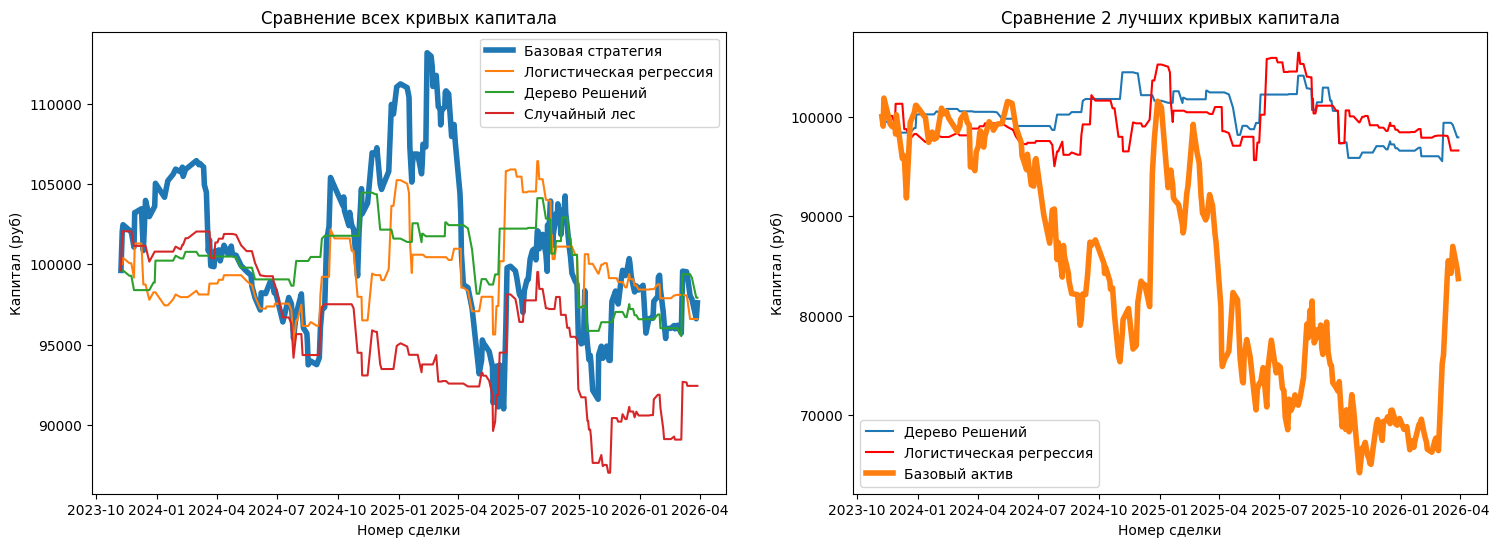

In [42]:
def final_result(data, log_list, tree_list, random_forest_list, y_test_graph, share):
    """Функция для визуализации результатов стратегий

    Args:
        data (pd.DataFrame): Датафрейм со всеми признаками и целевой переменной
        log_list (np.array): Массив с результатами классификации для Логистической регрессии
        tree_list (np.array): Массив с результатами классификации для Дерева решений
        random_forest_list (np.array): Массив с результатами классификации для Случайного леса
    """
    y = y_test_graph[:, 1]
    new_df = pd.merge(share, pd.Series(y, name='time'))
    initial_price = new_df.loc[0, 'close']
    new_df['close'] = (new_df['close'] / initial_price) * 100_000
    
    y = np.array(data['profit_percent_net'])
    n = int(len(y) * 0.8)
    y_test = y[n:]
    
    df_result = pd.DataFrame({'profit_base' : y_test / 100, 'log' : log_list, 'dec_tree' : tree_list, 'random_forest' : random_forest_list})
    df_result['log_profit'] = df_result.apply(lambda row: row['profit_base'] if row['log']== 1 else 0, axis=1)
    df_result['dec_tree_profit'] = df_result.apply(lambda row: row['profit_base'] if row['dec_tree']== 1 else 0, axis=1)
    df_result['random_forest_profit'] = df_result.apply(lambda row: row['profit_base'] if row['random_forest']== 1 else 0, axis=1)
    dict_result = {}
    for name in ['log', 'dec_tree', 'random_forest']:
        list_result = []
        res = 100_000
        for i, profit in enumerate(df_result[f'{name}_profit']):
            if i == 0 and profit == 0:
                list_result.append(100_000)
            elif profit != 0:
                res = res*(1 + profit)
                list_result.append(res)
            elif profit == 0:
                list_result.append(res)
        dict_result[name] = list_result
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.lineplot(y=(100_000 * np.cumprod(1 + df_result['profit_base'])), x=y_test_graph[:, 1], ax=axes[0], linewidth=4, label='Базовая стратегия')
    sns.lineplot(y=dict_result['log'], x=y_test_graph[:, 1], ax=axes[0], label='Логистическая регрессия')
    sns.lineplot(y=dict_result['dec_tree'], x=y_test_graph[:, 1], ax=axes[0], label='Дерево Решений')
    sns.lineplot(y=dict_result['random_forest'], x=y_test_graph[:, 1], ax=axes[0], label='Случайный лес')
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    
    # Определение лучших стратегий
    max_dict = {'Базовая стратегия' : np.array(np.cumprod(1 + df_result['profit_base'])), 
                'Логистическая регрессия' : np.array(dict_result['log']), 
                'Дерево Решений' : np.array(dict_result['dec_tree']), 
                'Случайный лес' : np.array(dict_result['random_forest'])}
    max_arg1 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array1 = max_dict[max_arg1]
    del max_dict[max_arg1]
    max_arg2 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array2 = max_dict[max_arg2]
    

    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], label=max_arg1)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], label=max_arg2, color='red')
    sns.lineplot(y=new_df['close'], x=y_test_graph[:, 1], ax=axes[1], label='Базовый актив', linewidth=4)
    axes[1].set_xlabel('Номер сделки')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших кривых капитала')
    
    return (max_array1, max_arg1), (max_array2, max_arg2), np.array(np.cumprod(1 + df_result['profit_base']))
            
g = final_result(df_ml, result_log_reg_hypper, 
             result_dec_tree_hypper_without_features, 
             result_random_forest_with_features, y_test, tatneft_graph)



In [43]:
# Итоговые расчеты
# Доходность за период
total_return_base_strategy = np.round((g[-1][-1] - 1) * 100, 2)
total_return_strategy_1 = np.round(((g[0][0] / 100_000)[-1] - 1) * 100, 2)
total_return_strategy_2 = np.round(((g[1][0] / 100_000)[-1] - 1) * 100, 2)

# Профит фактор
def profit_factor(x):
    pnl = np.diff(x) / 100_000
    pnl_plus = np.sum(pnl[pnl > 0])
    pnl_minus = np.abs(np.sum(pnl[pnl < 0]))
    return np.round(pnl_plus / pnl_minus, 2)

pr_f_base_strategy = profit_factor(g[-1])
pr_f_strategy_1 = profit_factor(g[0][0])
pr_f_strategy_2 = profit_factor(g[1][0])

# Средняя прибыль и средний убыток за сделку
def mean_pr_loss(x):
    pnl = np.diff(x) / 100_000
    pnl_plus_mean = np.round(np.mean(pnl[pnl > 0]) * 100, 2)
    pnl_minus_mean = np.round(np.mean(np.abs(pnl[pnl < 0])) * 100, 2)
    return pnl_plus_mean, pnl_minus_mean
    
mean_profit_base_strategy, mean_loss_base_strategy = mean_pr_loss(g[-1] * 100_000)
mean_profit_strategy_1, mean_loss_strategy_1 = mean_pr_loss(g[0][0])
mean_profit_strategy_2, mean_loss_strategy_2 = mean_pr_loss(g[1][0])

# win_rate
def win_rate(x):
    pnl = np.diff(x) / 100_000
    pnl_plus_count = len((pnl[pnl >= 0]) * 100)
    pnl_minus_count = len((pnl[pnl < 0]) * 100)
    winrate = np.round(pnl_plus_count / (pnl_plus_count + pnl_minus_count), 3) * 100
    return winrate
    
win_rate_base_strategy = win_rate(g[-1])
win_rate_strategy_1 = win_rate(g[0][0])
win_rate_strategy_2 = win_rate(g[1][0])

In [44]:
pd.DataFrame(columns=['total return', 'profit factor', 'mean_profit', 'mean_loss', 'win rate'],
             data=[[total_return_base_strategy, pr_f_base_strategy, mean_profit_base_strategy, mean_loss_base_strategy, win_rate_base_strategy],
                   [total_return_strategy_1, pr_f_strategy_1, mean_profit_strategy_1, mean_loss_strategy_1, win_rate_strategy_1], 
                   [total_return_strategy_2, pr_f_strategy_2, mean_profit_strategy_2, mean_loss_strategy_2, win_rate_strategy_2]],
             index=['base_strategy', f'{g[0][1]}', f'{g[1][1]}'])

,total return,profit factor,mean_profit,mean_loss,win rate
base_strategy,-2.40,0.98,1.05,0.91,45.9
Дерево Решений,-2.08,0.94,1.03,0.78,86.5
Логистическая регрессия,-3.40,0.93,1.08,0.90,79.5


In [45]:
y_for_var = y_for_var.to_frame()

In [46]:
y_for_var['Loss'] = y_for_var['profit_percent_net'].apply(lambda x: 1 if x <= 0 else 0)
y_for_var['Win'] = y_for_var['profit_percent_net'].apply(lambda x: 1 if x >= 0 else 0)
std_y = np.std(y_for_var['profit_percent_net'])
y_for_var['Big Win'] = y_for_var['profit_percent_net'].apply(lambda x : 1 if x >= std_y else 0)
y_for_var['Big Loss'] = y_for_var['profit_percent_net'].apply(lambda x : 1 if x <= -std_y else 0)
y_for_var

,profit_percent_net,Loss,Win,Big Win,Big Loss
318,-2.019,1,0,0,1
414,1.758,0,1,0,0
498,-3.427,1,0,0,1
559,1.503,0,1,0,0
632,-0.904,1,0,0,0
...,...,...,...,...,...
185609,-0.229,1,0,0,0
185828,-1.263,1,0,0,0
186008,-0.216,1,0,0,0
186341,-1.257,1,0,0,0


In [47]:
y_for_var['Win_pred'] = y_for_var['Win'].shift(1)
y_for_var['Big Win_pred'] = y_for_var['Big Win'].shift(1)
y_for_var['Loss_pred'] = y_for_var['Loss'].shift(1)
y_for_var['Big Loss_pred'] = y_for_var['Big Loss'].shift(1)
y_for_var.dropna(inplace=True)


In [48]:
np.round(pd.crosstab(index=y_for_var['Win'], columns=y_for_var['Win_pred'], normalize='columns'), 2)

Win_pred,0.0,1.0
Win,,
0,0.51,0.51
1,0.49,0.49


In [49]:
np.round(pd.crosstab(index=y_for_var['Loss'], columns=y_for_var['Loss_pred'], normalize='columns'), 2)

Loss_pred,0.0,1.0
Loss,,
0,0.49,0.49
1,0.51,0.51


In [50]:
np.round(pd.crosstab(index=y_for_var['Big Win'], columns=y_for_var['Big Win_pred'], normalize='columns'), 2)

Big Win_pred,0.0,1.0
Big Win,,
0,0.89,0.84
1,0.11,0.16


In [51]:
np.round(pd.crosstab(index=y_for_var['Big Loss'], columns=y_for_var['Big Loss_pred'], normalize='columns'), 2)

Big Loss_pred,0.0,1.0
Big Loss,,
0,0.9,0.9
1,0.1,0.1


In [52]:
y_for_var['count_of_trades'] = np.arange(1, len(y_for_var) + 1)
y_for_var['cumsum_loss'] = np.cumsum(y_for_var['Loss'])
y_for_var['cumsum_win'] = np.cumsum(y_for_var['Win'])
y_for_var['cumsum_big_win'] = np.cumsum(y_for_var['Big Win'])
y_for_var['cumsum_big_loss'] = np.cumsum(y_for_var['Big Loss'])

y_for_var['ratio_cumsum_loss_to_count_of_trades'] = np.round(y_for_var['cumsum_loss'] / y_for_var['count_of_trades'], 2)
y_for_var['ratio_cumsum_win_to_count_of_trades'] = np.round(y_for_var['cumsum_win'] / y_for_var['count_of_trades'], 2)
y_for_var['ratio_cumsum_big_loss_to_count_of_trades'] = np.round(y_for_var['cumsum_big_loss'] / y_for_var['count_of_trades'], 2)
y_for_var['ratio_cumsum_big_win_to_count_of_trades'] = np.round(y_for_var['cumsum_big_win'] / y_for_var['count_of_trades'], 2)

In [54]:
import pandas as pd
import numpy as np

# Загрузка данных (пример: колонки 'close' - цена закрытия)
# df = pd.read_csv('your_data.csv', parse_dates=['date'])
# df.set_index('date', inplace=True)

# Пример создания тестовых данных
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=500)
df = pd.DataFrame({'close': np.random.randn(500).cumsum() + 100}, index=dates)

# Параметры скользящих средних
fast_ma = 10   # быстрая MA
slow_ma = 30   # медленная MA

# Расчёт скользящих средних
df['MA_fast'] = df['close'].rolling(window=fast_ma).mean()
df['MA_slow'] = df['close'].rolling(window=slow_ma).mean()

# Сигналы:
# 1 - быстрая выше медленной (лонг)
# 0 - быстрая ниже или равна медленной
df['signal'] = np.where(df['MA_fast'] > df['MA_slow'], 1, 0)

# Момент пересечения (изменение сигнала)
df['position'] = df['signal'].diff()

# Вход в лонг (быстрая пересекла медленную снизу вверх)
df['entry'] = (df['position'] == 1)

# Выход из лонга (быстрая пересекла медленную сверху вниз)
df['exit'] = (df['position'] == -1)

# Формирование DataFrame со сделками
trades = []
in_trade = False
entry_price = None
entry_date = None

for idx, row in df.iterrows():
    if row['entry'] and not in_trade:
        # Открываем лонг
        in_trade = True
        entry_price = row['close']
        entry_date = idx
    elif row['exit'] and in_trade:
        # Закрываем лонг
        in_trade = False
        exit_price = row['close']
        trades.append({
            'entry_date': entry_date,
            'exit_date': idx,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'pnl': exit_price - entry_price,
            'pnl_percent': (exit_price / entry_price - 1) * 100
        })

# Преобразуем в DataFrame
trades_df = pd.DataFrame(trades)

# Вывод результатов
print("=== Последние строки исходного DataFrame ===")
print(df[['close', 'MA_fast', 'MA_slow', 'entry', 'exit']].tail(10))

print("\n=== Список сделок (только лонг) ===")
display(trades_df)

if not trades_df.empty:
    print(f"\n=== Статистика ===")
    print(f"Всего сделок: {len(trades_df)}")
    print(f"Средний PnL: {trades_df['pnl'].mean():.2f}")
    print(f"Суммарный PnL: {trades_df['pnl'].sum():.2f}")
    print(f"Процент прибыльных: {(trades_df['pnl'] > 0).mean() * 100:.1f}%")

=== Последние строки исходного DataFrame ===
                 close     MA_fast     MA_slow  entry   exit
2025-05-05  104.146938  104.155776  104.165069  False   True
2025-05-06  105.626882  104.028881  104.193429  False  False
2025-05-07  105.704250  104.070366  104.247693  False  False
2025-05-08  104.842966  104.005378  104.266114  False  False
2025-05-09  106.366090  104.168336  104.339050  False  False
2025-05-10  106.905000  104.527411  104.437315   True  False
2025-05-11  105.867754  104.847419  104.480534  False  False
2025-05-12  105.677415  105.256548  104.492157  False  False
2025-05-13  104.801797  105.409400  104.492277  False  False
2025-05-14  103.418997  105.335809  104.465497  False  False

=== Список сделок (только лонг) ===


,entry_date,exit_date,entry_price,exit_price,pnl,pnl_percent
0,2024-03-12,2024-03-28,92.469581,91.123755,-1.345826,-1.455426
1,2024-04-01,2024-04-02,92.172985,91.470932,-0.702053,-0.761669
2,2024-04-30,2024-05-17,91.290745,88.653339,-2.637406,-2.889018
3,2024-06-11,2024-07-16,90.154717,92.930569,2.775851,3.078986
4,2024-07-29,2024-08-24,98.553229,99.046324,0.493095,0.500334
5,2024-09-11,2024-09-23,100.686503,96.859914,-3.826590,-3.800499
6,2024-10-16,2024-12-10,96.462822,103.499890,7.037068,7.295109
7,2025-01-03,2025-02-09,103.563577,107.050650,3.487073,3.367084
8,2025-02-10,2025-02-11,105.983030,105.840651,-0.142379,-0.134342
9,2025-02-25,2025-03-20,112.119479,108.058926,-4.060553,-3.621630



=== Статистика ===
Всего сделок: 11
Средний PnL: -0.01
Суммарный PnL: -0.06
Процент прибыльных: 36.4%
